In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
def lorenz(t, W, sigma, r, b):
    """ Lorenz system of ODEs
    
    Parameters
    ----------
    t : float
        current time step value
    W : list of float (length 3)
        consists of current values of X, Y, and Z
    sigma : float
        the Prandtl number
    r : float
        the Rayleigh number
    b : float
        dimensionless length scale
    
    Returns
    -------
    list of float (length 3)
        the derivative values of each of X, Y, and Z
    """
    X, Y, Z = W
    
    dX = -sigma*(X - Y)
    dY = r*X - Y - X*Z
    dZ = -b*Z + X*Y
    
    return [dX, dY, dZ]

In [3]:
t = 60
dt = 0.01
t_eval = np.linspace(0, 60, 2*6000+1)

W_0 = [0, 1, 0]
sigma = 10
r = 28
b = 8/3

sol = solve_ivp(lorenz, [0, t], W_0, args=[sigma, r, b], t_eval=t_eval)

<Figure size 432x288 with 0 Axes>

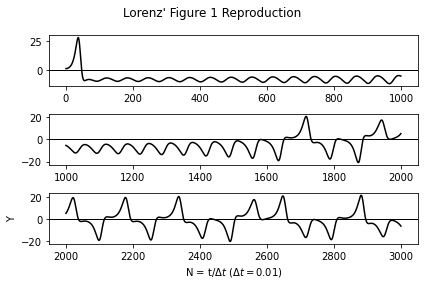

In [4]:
N = sol.t / dt
X, Y, Z = sol.y

plt.figure()
fig, axes = plt.subplots(3, 1)
fig.suptitle("Lorenz' Figure 1 Reproduction")
for i in range(3):
    index_range = (N >= i*1000) & (N < (i+1)*1000)
    axes[i].axhline(y=0, color="black", lw=1)
    axes[i].plot(N[index_range], Y[index_range], color="black")
plt.xlabel("N = t/$\\Delta t$ ($\\Delta t = 0.01$)")
plt.ylabel("Y")
plt.tight_layout()

plt.savefig("q2_fig1.png")

<Figure size 768x1536 with 0 Axes>

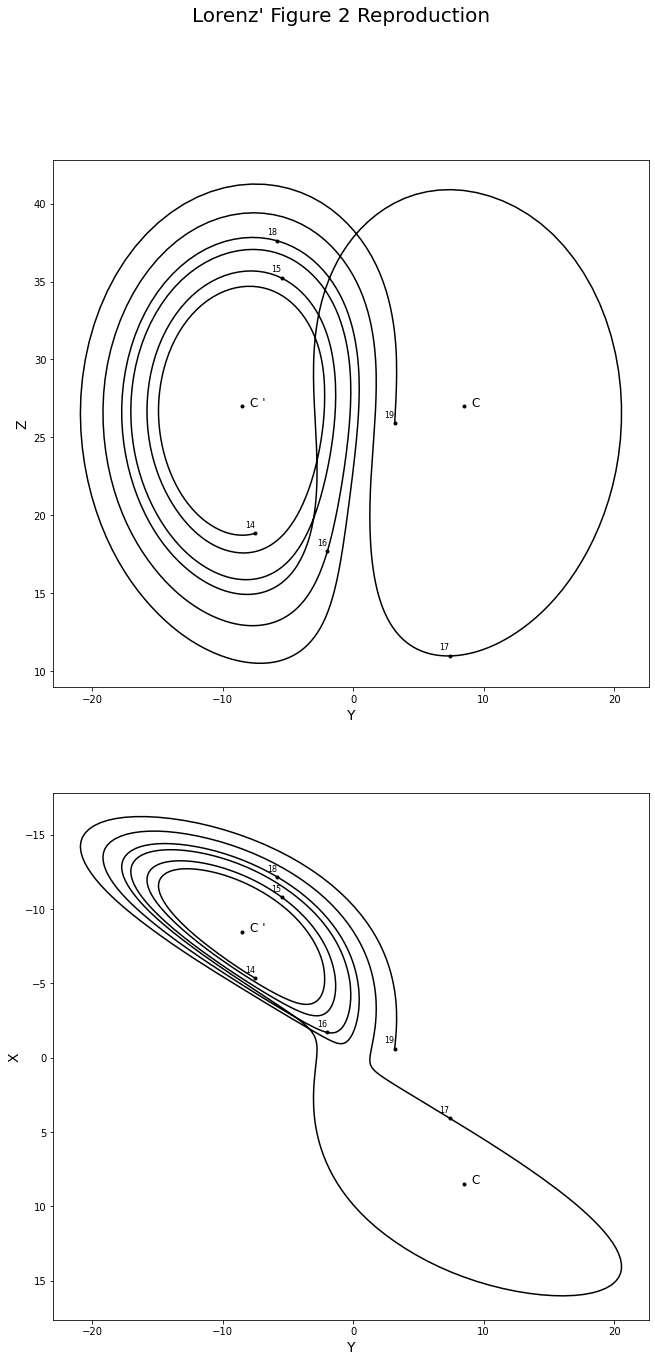

In [5]:
index_range = (N >= 1400) & (N <= 1900)

resolution = 768
dpi = plt.rcParams['figure.dpi']
figsize = (resolution/dpi, 2*resolution/dpi)

plt.figure(figsize=figsize)
fig, axes = plt.subplots(2, 1, figsize=figsize)
fig.suptitle("Lorenz' Figure 2 Reproduction", fontsize=20)

axes[0].plot(Y[index_range], Z[index_range], color="black")
axes[1].plot(Y[index_range], X[index_range], color="black")
for i in range(14, 19+1):
    point_mask = N == i*100
    axes[0].plot(Y[point_mask], Z[point_mask], marker='.', color="black")
    axes[0].text(Y[point_mask]-0.8, Z[point_mask]+0.4, str(i), fontsize=8, color="black")
    axes[1].plot(Y[point_mask], X[point_mask], marker='.', color="black")
    axes[1].text(Y[point_mask]-0.8, X[point_mask]-0.4, str(i), fontsize=8, color="black")
for p in [(6*np.sqrt(2), 6*np.sqrt(2), 27, "C"), (-6*np.sqrt(2), -6*np.sqrt(2), 27, "C '")]:
    axes[0].plot(p[1], p[2], marker='.', color="black")
    axes[0].text(p[1]+0.6, p[2], p[3], color="black", fontsize=12)
    axes[1].plot(p[1], p[0], marker='.', color="black")
    axes[1].text(p[1]+0.6, p[0], p[3], color="black", fontsize=12)
    
axes[1].invert_yaxis()

axes[0].set_ylabel("Z", fontsize=14)
axes[0].set_xlabel("Y", fontsize=14)
axes[1].set_ylabel("X", fontsize=14)
axes[1].set_xlabel("Y", fontsize=14)

plt.savefig("q2_fig2.png")

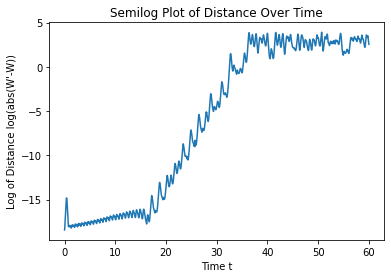

In [6]:
W_0_prime = np.array(W_0) + [0, 1e-8, 0]

sol2 = solve_ivp(lorenz, [0, t], W_0_prime, args=[sigma, r, b], t_eval=t_eval)

X_prime, Y_prime, Z_prime = sol2.y

W_diff = np.sqrt((X_prime-X)**2 + (Y_prime-Y)**2 + (Z_prime-Z)**2)

plt.figure()
plt.title("Semilog Plot of Distance Over Time")
plt.plot(sol.t, np.log(W_diff))
plt.xlabel("Time t")
plt.ylabel("Log of Distance log(abs(W'-W))")

plt.savefig("q2_fig3.png")